In [2]:
# Importing the required moduels

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [4]:
#  download  and convert the raw images to tensor so that we can process

In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root= './data',
    train= True,
    download= True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root= './data',
    train= False,
    download= True,
    transform=transform
)

In [6]:
# creating test and train loader

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size= 64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size= 64,
    shuffle=False
)

```
MNIST image
[1 × 28 × 28]
       │
       ▼
┌─────────────────┐
│ Conv2D           │
│ 1 → 32 channels  │
│ 3×3 kernel       │
└─────────────────┘
       │
       ▼
[32 × 28 × 28]
       │
       ▼
     ReLU
       │
       ▼
┌─────────────────┐
│ MaxPool 2×2      │
└─────────────────┘
       │
       ▼
[32 × 14 × 14]
       │
       ▼
┌─────────────────┐
│ Conv2D           │
│ 32 → 64          │
│ 3×3 kernel       │
└─────────────────┘
       │
       ▼
[64 × 14 × 14]
       │
       ▼
     ReLU
       │
       ▼
     MaxPool
       │
       ▼
[64 × 7 × 7]
       │
       ▼
     Flatten
       │
       ▼
3136 values
       │
       ▼
Linear
3136 → 10
       │
       ▼
10 logits
       │
       ▼
Predicted digit
```

In [8]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   
        )

        self.classifier = nn.Linear(64*7*7,10)

    def forward(self,x):

        x = self.features(x)

        x = torch.flatten(x,1)

        x = self.classifier(x)

        return x

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [10]:
model = SimpleCNN().to(device)

In [11]:
# MNIST is 10-class classification problem so we gonna use crossentropy as loss function

In [12]:
criterion = nn.CrossEntropyLoss()

In [13]:
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [14]:
# Training Loop

In [15]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # clearing the old gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)

        # calculate loss 
        loss = criterion(outputs,labels)

        # Backpropogation
        loss.backward()
        
        # update the weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = (running_loss) / len(train_loader)

    print(
        f'Epoch: {epoch+1} | '
        f'Loss: {average_loss:.4f}'
    )

Epoch: 1 | Loss: 0.1766
Epoch: 2 | Loss: 0.0532
Epoch: 3 | Loss: 0.0386
Epoch: 4 | Loss: 0.0304
Epoch: 5 | Loss: 0.0255


In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        
        predicted = torch.argmax(outputs, dim=1)

        total+=labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f'Test Accuracy: {accuracy:.2f} %')

Test Accuracy: 98.68 %


In [22]:
model.eval()

wrong_examples = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        wrong = predictions != labels

        for image, label, prediction in zip(
            images[wrong],
            labels[wrong],
            predictions[wrong]
        ):
            wrong_examples.append(
                (image.cpu(), label.item(), prediction.item())
            )

print("Number of wrong predictions:", len(wrong_examples))

Number of wrong predictions: 132


In [23]:
# analyze the wrong predictions 

In [24]:
from collections import Counter

confusions = Counter()

for image, actual, predicted in wrong_examples:
    confusions[(actual, predicted)] += 1

for (actual, predicted), count in confusions.most_common():
    print(
        f"Actual: {actual} → Predicted: {predicted} | Count: {count}"
    )

Actual: 9 → Predicted: 5 | Count: 12
Actual: 8 → Predicted: 2 | Count: 12
Actual: 9 → Predicted: 4 | Count: 11
Actual: 7 → Predicted: 2 | Count: 10
Actual: 3 → Predicted: 5 | Count: 7
Actual: 9 → Predicted: 7 | Count: 7
Actual: 6 → Predicted: 5 | Count: 7
Actual: 8 → Predicted: 0 | Count: 6
Actual: 6 → Predicted: 0 | Count: 4
Actual: 5 → Predicted: 3 | Count: 4
Actual: 8 → Predicted: 5 | Count: 4
Actual: 2 → Predicted: 7 | Count: 3
Actual: 8 → Predicted: 7 | Count: 3
Actual: 3 → Predicted: 2 | Count: 3
Actual: 9 → Predicted: 3 | Count: 3
Actual: 1 → Predicted: 2 | Count: 3
Actual: 8 → Predicted: 9 | Count: 2
Actual: 7 → Predicted: 1 | Count: 2
Actual: 1 → Predicted: 5 | Count: 2
Actual: 6 → Predicted: 1 | Count: 2
Actual: 9 → Predicted: 0 | Count: 2
Actual: 2 → Predicted: 4 | Count: 2
Actual: 8 → Predicted: 1 | Count: 1
Actual: 4 → Predicted: 6 | Count: 1
Actual: 0 → Predicted: 6 | Count: 1
Actual: 8 → Predicted: 3 | Count: 1
Actual: 7 → Predicted: 9 | Count: 1
Actual: 9 → Predicted: 2

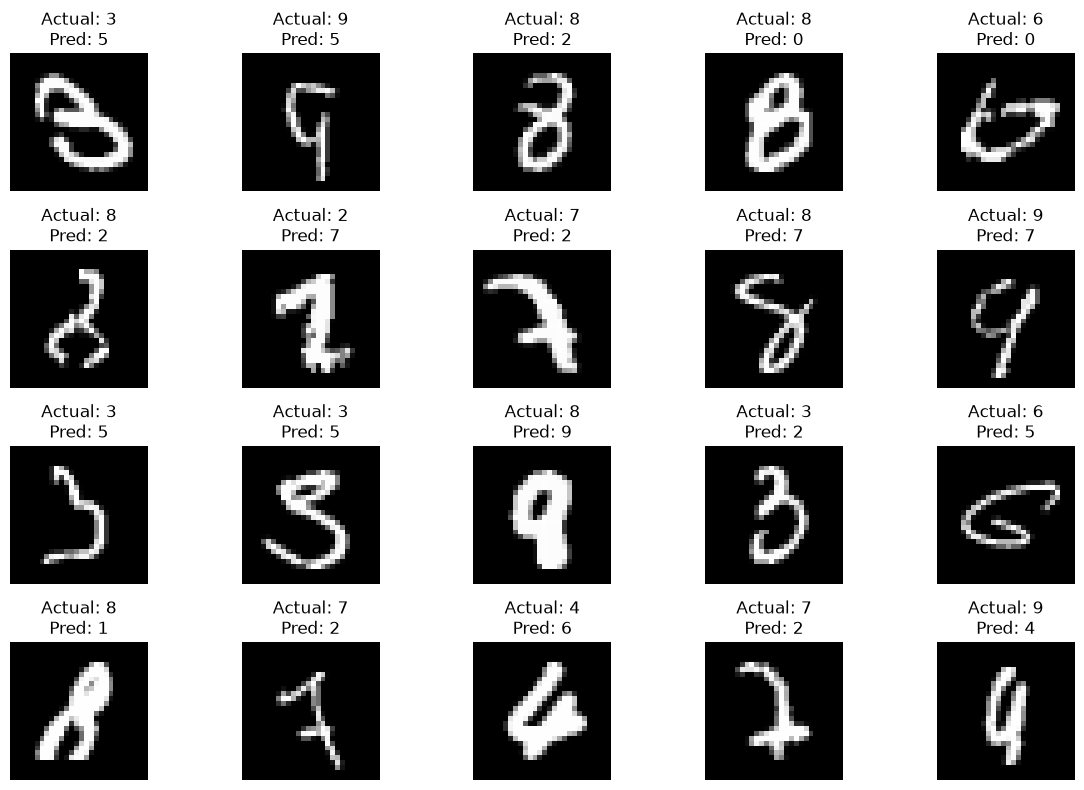

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(min(20, len(wrong_examples))):

    image, actual, predicted = wrong_examples[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(
        f"Actual: {actual}\nPred: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
import torch

image, actual, predicted = wrong_examples[0]

image_input = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    logits = model(image_input)

probabilities = torch.softmax(logits, dim=1)

print("Actual:", actual)
print("Predicted:", predicted)

print("\nLogits:")
print(logits.squeeze())

print("\nProbabilities:")
print(probabilities.squeeze())

Actual: 3
Predicted: 5

Logits:
tensor([-10.3235, -20.6871,   0.0891,   1.3253, -16.2695,   1.5928, -14.5107,
        -11.4482,  -0.5661, -14.5577])

Probabilities:
tensor([3.1767e-06, 1.0025e-10, 1.0571e-01, 3.6390e-01, 8.3107e-09, 4.7549e-01,
        4.8246e-08, 1.0315e-06, 5.4898e-02, 4.6033e-08])


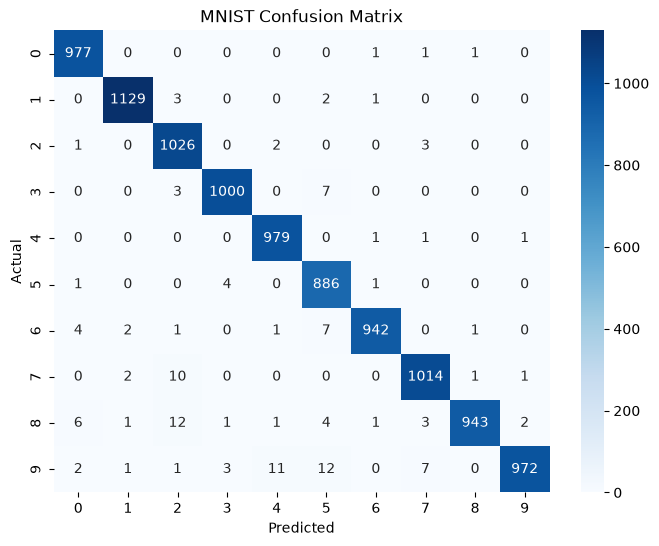

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")

plt.show()

## Experiment 1: Simple CNN on MNIST — Complete Notes

> **Status: ✅ COMPLETED**

This block took us through the complete practical CNN workflow:

```text
UNDERSTAND
    ↓
IMPLEMENT
    ↓
TRAIN
    ↓
EVALUATE
    ↓
ANALYZE PREDICTIONS
    ↓
ANALYZE LOGITS / PROBABILITIES
    ↓
ANALYZE CONFUSION MATRIX
    ↓
UNDERSTAND MODEL ERRORS
```

---

# 1. 🎯 Experiment Goal

Build a **simple CNN using PyTorch** to classify MNIST handwritten digits:

```text
0 1 2 3 4 5 6 7 8 9
```

MNIST consists of grayscale handwritten-digit images. In our implementation, each image is represented as:

```text
[1, 28, 28]
```

where:

```text
1  → grayscale channel
28 → height
28 → width
```

A batch of 64 images therefore has:

```text
[64, 1, 28, 28]
```

PyTorch's `torchvision.datasets.MNIST` provides the dataset and returns an image together with its target class index. ([PyTorch Documentation][1])

---

# 2. 🧠 Why CNN instead of a normal ANN?

A normal ANN could flatten the image:

```text
28 × 28
   ↓
784 values
```

and process:

```text
[784]
```

But this destroys the explicit 2D spatial arrangement.

A CNN preserves the spatial structure:

```text
28 × 28 image
     ↓
local patterns
     ↓
feature maps
     ↓
higher-level features
     ↓
digit classification
```

The CNN can therefore learn useful local structures such as:

```text
edges
  ↓
curves
  ↓
combinations of strokes
  ↓
digit-specific patterns
```

---

# 3. 🖼️ CNN visual

![Image](https://images.openai.com/static-rsc-4/2Lx50Umzezvg4S0nkPyG0tX_yj7I9DLBR2GGxPRqVKQE_6gZkJbAP4w2S7l_Auzm2HVpfHu2knbbnXRq2-9Bok-9dnukj5VrSkuZvjtVg-cy4-YSYoQOdqWxniWR6GWEhXGAMNTgplXEC9o0kToCTTh5vbn3Tf56xvmeCJLalESIbJYF9_2VcOiA0F-JP0rO?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/SfgUPcjDI22XzeCVPtvbnZ3GIW_Xkep2tk7InKKvlWie7EJQv4dWr3_1xqAbycqZ_FI3boezH88-AXnIMaUfWfKCSURy3eJ-lYOfosE1LPTVmbU4xVEnO0VC0MBZNRLjsrJVGaV4pLDroSa66v192UTifNIEaD8OL6CPEEIaO9MixMmklClHl91zAd3GhiMI?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/HSqKe__YhUzjB2CzX4WDCgF8fZyFgJo_5HSV3lDs6gQWyyoI9VpVBM1jvk_07a345YGXsRmYcZNMxKD85ugbGlKzYLoQlxv3yOPHgP4_tV1fUHHXZvpYQOaTJaHTr1TgP0Quh-dA5nr-PyXG7GhOSLKxR4TwqUwLze3rYuvRPXiwjPE6FMDLzj6a10ZwhcHY?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/6NBISnzcdgrGdf0O9-yYCsL_aAXxgh7LAbGB7JSfBcNiRJJfMf1vziDu4cZWsp7eyJQUEW37QQ_b4DItzUypWeMKxalZxYdokF4QFW145xc-V5Ilb47ZKhKb3o2fe7GEirJnNgvy6K9CwWjN460tYulRjY7BXQQ0k_c3LjZCn_WcU_grmMQON60LU4vwEEYj?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/t3-ZrgX5G9-G6tKaezEREOBFF_0hFCBbxmqoPTQLlKHhU8VTYOzH_7kcLII9GXsglp3244QvRmAtZig9hpbfc6tOhmZYy642JHk7GCkOZV6owuf1stBK24nuaBwfnyyVqtuwyfmgy7J-a1FY1yCQLLSgHxyn7BJDRAi37v8SInasCqYkTbrSpcmHIljcxkwD?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/Y55BsnGN_QrLCuWgnefvvk5sQbikb76k_dKY9Ml0r92QoNjJAoU8F9BkdpwR6o69Vr0ooITSGaUoDDOKdTBAPxwKvTD1A_H3SBd13M11yFwZknGFudC863GlH80HYDkJmIV_8OEVfMZZc4KJLmpCwfJ0JRH7VygSrrdaOY7sWU-tSiqnkr_32utuU9ctpiea?purpose=fullsize)

The important idea is:

```text
Image
 ↓
Convolution
 ↓
Feature maps
 ↓
Pooling
 ↓
More convolution
 ↓
Flatten
 ↓
Classifier
```

For an interactive explanation of convolution and feature maps:

[CNN Explainer — Georgia Tech Polo Club](https://poloclub.github.io/cnn-explainer/?utm_source=chatgpt.com)

---

# 4. 🏗️ Our CNN Architecture

The model we implemented:

```text
Input
[1 × 28 × 28]
       ↓
Conv2d(1 → 32, 3×3, padding=1)
       ↓
ReLU
       ↓
MaxPool 2×2
       ↓
[32 × 14 × 14]
       ↓
Conv2d(32 → 64, 3×3, padding=1)
       ↓
ReLU
       ↓
MaxPool 2×2
       ↓
[64 × 7 × 7]
       ↓
Flatten
       ↓
3136
       ↓
Linear(3136 → 10)
       ↓
10 logits
```

PyTorch's `Conv2d` accepts input in the form `(N, C, H, W)` and produces `(N, C_out, H_out, W_out)`. Its output spatial dimensions depend on kernel size, stride, padding, and dilation. ([PyTorch Documentation][2])

---

# 5. 📐 Tensor Shape Flow

This is one of the **most important things to remember**.

Starting with:

```text
[64, 1, 28, 28]
```

### First convolution

```text
Conv2d(1, 32, 3, padding=1)

[64, 1, 28, 28]
        ↓
[64, 32, 28, 28]
```

### ReLU

```text
[64, 32, 28, 28]
        ↓
[64, 32, 28, 28]
```

ReLU doesn't change the shape.

### MaxPool

```text
[64, 32, 28, 28]
        ↓
[64, 32, 14, 14]
```

Spatial dimensions are halved.

### Second convolution

```text
[64, 32, 14, 14]
        ↓
[64, 64, 14, 14]
```

### Second pooling

```text
[64, 64, 14, 14]
        ↓
[64, 64, 7, 7]
```

### Flatten

```text
[64, 64, 7, 7]
        ↓
[64, 3136]
```

because:

$$
64\times7\times7=3136
$$

### Final Linear layer

```text
[64, 3136]
      ↓
[64, 10]
```

The final `10` represents the ten digit classes.

---

# 6. 🔢 Why does `padding=1` preserve 28×28?

For a standard convolution:

$$
H_{out}
=
\left\lfloor
\frac{H_{in}+2P-K}{S}
\right\rfloor+1
$$

For our first convolution:

```text
H = 28
K = 3
P = 1
S = 1
```

Therefore:

$$
H_{out}
=
\frac{28+2(1)-3}{1}+1
$$

$$
=28
$$

So:

```text
28 × 28
   ↓
28 × 28
```

The same happens to width.

---

# 7. 🧩 What does `out_channels=32` mean?

This is important.

```python
nn.Conv2d(1, 32, kernel_size=3, padding=1)
```

means:

```text
Input channels = 1
Output channels = 32
```

The layer learns **32 filters**.

Conceptually:

```text
Input image
     │
     ├── Filter 1 → Feature map 1
     ├── Filter 2 → Feature map 2
     ├── Filter 3 → Feature map 3
     ├── ...
     └── Filter 32 → Feature map 32
```

Therefore:

```text
1 image
 ↓
32 learned feature maps
```

PyTorch defines `out_channels` as the number of channels produced by the convolution. ([PyTorch Documentation][2])

---

# 8. ⚡ ReLU

ReLU:

$$
ReLU(x)=\max(0,x)
$$

Example:

```text
Input:
[-3, -1, 2, 5]

ReLU:
[ 0,  0, 2, 5]
```

### Why?

It introduces non-linearity into the network.

Without nonlinear activations, stacking linear operations would still result in an overall linear transformation.

---

# 9. 🧊 Max Pooling

We used:

```python
nn.MaxPool2d(2)
```

A `2×2` region is examined and the largest value is selected.

Example:

```text
[1  5]
[3  2]
```

becomes:

```text
5
```

So:

```text
28 × 28
    ↓
14 × 14
```

Pooling reduces spatial resolution while retaining strong activations.

---

# 10. 🔄 Flatten

Before flattening:

```text
[64, 64, 7, 7]
```

For each image:

$$
64\times7\times7=3136
$$

Therefore:

```python
x = torch.flatten(x, 1)
```

produces:

```text
[64, 3136]
```

The `1` means:

> Preserve the batch dimension and flatten everything after it.

---

# 11. 🎯 Why 10 outputs?

MNIST has 10 classes:

```text
index → digit

0 → 0
1 → 1
2 → 2
3 → 3
4 → 4
5 → 5
6 → 6
7 → 7
8 → 8
9 → 9
```

Therefore:

```python
nn.Linear(3136, 10)
```

produces:

```text
[batch_size, 10]
```

For one image:

```text
10 numbers
```

Each position corresponds to one class.

---

# 12. 🔥 Logits — very important

The output of the final layer is **not automatically probability**.

Example:

```text
[-12.3991, -6.7920, -0.3152, 0.9607,
 -11.5050, -5.5450, -25.4667,
 16.4732, -9.3058, -0.5950]
```

These are **logits**.

Mapping:

```text
index 0 → logit for digit 0
index 1 → logit for digit 1
...
index 7 → logit for digit 7
...
index 9 → logit for digit 9
```

The largest value was:

$$
16.4732
$$

at index 7.

Therefore:

```python
prediction = output.argmax()
```

returns:

```text
7
```

---

# 13. 🧠 How did the network learn that index 7 means digit 7?

This was one of the most important doubts in the experiment.

The model doesn't magically know:

> "Position 7 means digit 7."

The association comes from the **training labels**.

Suppose:

```text
Image → handwritten 7
Label → 7
```

The final layer produces 10 logits.

If the model initially predicts:

```text
2
```

while the true label is:

```text
7
```

the loss produces gradients that adjust the network's parameters so that, for similar examples, the score for class 7 becomes more favorable.

Repeated over many labeled examples:

```text
image of 0 → strengthen class 0
image of 1 → strengthen class 1
...
image of 7 → strengthen class 7
...
image of 9 → strengthen class 9
```

Eventually the network learns a mapping:

```text
visual features
      ↓
class-specific scores
      ↓
highest score
      ↓
predicted class
```

---

# 14. 📊 Logits → Probabilities

Softmax converts logits into probabilities:

$$
P_i=
\frac{e^{z_i}}
{\sum_j e^{z_j}}
$$

For the earlier example, the large class-7 logit makes the probability for class 7 dominate.

Conceptually:

```text
Logits
   ↓
Softmax
   ↓
Probabilities
   ↓
argmax
   ↓
Predicted digit
```

### Important PyTorch detail

With:

```python
nn.CrossEntropyLoss()
```

you normally **do not add Softmax to the final model output**.

PyTorch's documentation explains that `CrossEntropyLoss` works with logits and combines the relevant log-softmax and negative-log-likelihood operations. ([PyTorch Documentation][3])

For analysis, however, you can explicitly calculate:

```python
probabilities = torch.softmax(logits, dim=1)
```

---

# 15. 🧪 Your Actual Training Result

You trained for 5 epochs:

```text
Epoch 1 → Loss: 0.1766
Epoch 2 → Loss: 0.0532
Epoch 3 → Loss: 0.0386
Epoch 4 → Loss: 0.0304
Epoch 5 → Loss: 0.0255
```

### Loss trend

```text
0.1766
   ↓
0.0532
   ↓
0.0386
   ↓
0.0304
   ↓
0.0255
```

The loss consistently decreased.

That indicates the optimization process was successfully reducing the training objective.

PyTorch's standard training workflow is essentially:

```text
zero gradients
     ↓
forward
     ↓
calculate loss
     ↓
backward
     ↓
optimizer step
```

PyTorch documents `zero_grad()`, `backward()`, and `optimizer.step()` as the core optimization-loop operations. ([PyTorch Documentation][3])

---

# 16. 🎯 Your Test Accuracy

You achieved:

$$
\boxed{98.68\%}
$$

On 10,000 test images:

$$
10000\times0.9868=9868
$$

Therefore:

```text
Correct = 9,868
Wrong   = 132
```

Your confusion matrix confirms:

$$
\boxed{9868/10000}
$$

correct predictions.

---

# 17. 📉 Accuracy vs Loss

Don't confuse these two.

### Loss

Measures how well the predicted output agrees with the target according to the chosen loss function.

### Accuracy

Measures:

```text
Was the predicted class correct?
```

Example:

```text
Actual = 7

Prediction A:
7 → 51%
3 → 49%

Prediction B:
7 → 99%
3 → 1%
```

Both are:

```text
Correct according to argmax
```

but the model's confidence/distribution is different.

Therefore:

> **Loss and accuracy measure different properties of model behavior.**

---

# 18. 🔬 Error Analysis

You found:

```text
132 wrong predictions
```

Instead of stopping at accuracy, we inspected the mistakes.

This is an important ML workflow:

```text
Accuracy
   ↓
Which samples are wrong?
   ↓
Which classes are confused?
   ↓
Why are they confused?
```

---

# 19. 🖼️ Wrong Prediction Analysis

You visualized incorrect predictions such as:

```text
Actual 3 → Predicted 5
Actual 9 → Predicted 5
Actual 8 → Predicted 2
Actual 8 → Predicted 0
Actual 6 → Predicted 0
Actual 7 → Predicted 2
```

The important observation:

> The errors were **not random**.

The model tends to confuse visually similar handwritten forms.

For example:

```text
3 ↔ 5
8 ↔ 2
9 ↔ 5
9 ↔ 4
7 ↔ 2
6 ↔ 5
8 ↔ 0
```

This gives us information about the learned representation.

---

# 20. 🔥 Detailed Logit/Probability Error Example

One wrong prediction was:

```text
Actual:    3
Predicted: 5
```

### Logits

```text
0 → -10.3235
1 → -20.6871
2 →   0.0891
3 →   1.3253   ← actual
4 → -16.2695
5 →   1.5928   ← prediction
6 → -14.5107
7 → -11.4482
8 →  -0.5661
9 → -14.5577
```

Largest logit:

$$
1.5928
$$

Therefore:

```text
argmax → 5
```

---

# 21. 📊 Probabilities for that mistake

You calculated:

```text
0 → 0.00000318
1 → ~0
2 → 10.57%
3 → 36.39%
4 → ~0
5 → 47.55%
6 → ~0
7 → ~0
8 → 5.49%
9 → ~0
```

The important part:

```text
Actual class 3 → 36.39%
Predicted class 5 → 47.55%
```

So the model was **wrong but relatively uncertain**.

It wasn't:

```text
3 → 0.1%
5 → 99.9%
```

Instead:

```text
3 → 36.39%
5 → 47.55%
```

The two classes were relatively close.

The logit difference was:

$$
1.5928-1.3253=0.2675
$$

So this is a good example of an **ambiguous classification**.

---

# 22. 🧠 Important distinction: Confidence vs Correctness

A prediction can be:

### Correct + confident

```text
Actual = 7

7 → 99%
```

### Correct + uncertain

```text
Actual = 7

7 → 52%
1 → 48%
```

### Wrong + uncertain

Your example:

```text
Actual = 3

5 → 47.55%
3 → 36.39%
```

### Wrong + confident

Possible example:

```text
Actual = 3

5 → 99%
3 → 0.5%
```

This distinction becomes very important in later model evaluation.

---

# 23. 📊 Confusion Matrix

Your confusion matrix:

```text
Rows    → Actual
Columns → Predicted
```

So:

```text
cm[8][2] = 12
```

means:

> 12 actual 8s were predicted as 2.

The diagonal represents correct predictions:

```text
0 → 0
1 → 1
2 → 2
3 → 3
4 → 4
5 → 5
6 → 6
7 → 7
8 → 8
9 → 9
```

Everything outside the diagonal is an error.

---

# 24. 🔥 Your Actual Confusion Matrix Results

From your matrix:

| Actual digit | Correct | Wrong | Accuracy |
| -----------: | ------: | ----: | -------: |
|            0 |     977 |     3 |   99.69% |
|            1 |    1129 |     6 |   99.47% |
|            2 |    1026 |     6 |   99.42% |
|            3 |    1000 |    10 |   99.01% |
|            4 |     979 |     3 |   99.69% |
|            5 |     886 |     6 |   99.33% |
|            6 |     942 |    16 |   98.33% |
|            7 |    1014 |    14 |   98.64% |
|            8 |     943 |    31 |   96.82% |
|            9 |     972 |    37 |   96.33% |

Overall:

```text
10,000 test images
9,868 correct
132 wrong
```

---

# 25. 🔥 Major Confusion Patterns

The largest individual confusion pairs were:

```text
Actual 9 → Predicted 5 : 12
Actual 8 → Predicted 2 : 12
Actual 9 → Predicted 4 : 11
Actual 7 → Predicted 2 : 10
Actual 3 → Predicted 5 : 7
Actual 9 → Predicted 7 : 7
Actual 6 → Predicted 5 : 7
Actual 8 → Predicted 0 : 6
```

This tells us something important:

> The CNN's errors are concentrated in particular visual confusions rather than being uniformly distributed across all classes.

---

# 26. 🧠 Why do these mistakes happen?

The CNN doesn't understand:

> "This person intended to write a 9."

It processes:

```text
pixels
 ↓
local features
 ↓
higher-level features
 ↓
final representation
 ↓
class scores
```

Different handwritten forms can produce similar learned representations.

For example:

```text
Handwritten 9
     ↓
features
     ↓
similar to learned 5 representation
     ↓
score(5) > score(9)
     ↓
prediction = 5
```

This is a **feature-space classification problem**, not random guessing.

---

# 27. 🧮 Parameter Count

Our CNN has approximately **50,186 trainable parameters**.

### Conv1

```text
Input channels = 1
Output channels = 32
Kernel = 3×3
```

Weights:

$$
32\times1\times3\times3=288
$$

Bias:

$$
32
$$

Total:

$$
320
$$

---

### Conv2

$$
64\times32\times3\times3=18,432
$$

Bias:

$$
64
$$

Total:

$$
18,496
$$

---

### Linear

$$
3136\times10=31,360
$$

Bias:

$$
10
$$

Total:

$$
31,370
$$

---

### Total

$$
320+18,496+31,370
$$

$$
\boxed{50,186}
$$

---

# 28. 💻 Complete Implementation

```python
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# -----------------------------
# 1. Dataset
# -----------------------------

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# -----------------------------
# 2. DataLoaders
# -----------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# -----------------------------
# 3. CNN
# -----------------------------

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Linear(
            64 * 7 * 7,
            10
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x


# -----------------------------
# 4. Device
# -----------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SimpleCNN().to(device)


# -----------------------------
# 5. Loss + Optimizer
# -----------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# -----------------------------
# 6. Training
# -----------------------------

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    average_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        f"Epoch: {epoch + 1} | "
        f"Loss: {average_loss:.4f}"
    )


# -----------------------------
# 7. Evaluation
# -----------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

accuracy = (
    100 * correct / total
)

print(
    f"Test Accuracy: {accuracy:.2f}%"
)
```

PyTorch's official tutorials similarly use `nn.Module` to define models and a training loop built around datasets, forward passes, losses, backpropagation, and optimizer updates. ([PyTorch Documentation][4])

---

# 29. 🐛 Debugging Checklist

When a CNN doesn't work, don't immediately change the architecture.

Use:

```text
1. Data
      ↓
2. Labels
      ↓
3. Shapes
      ↓
4. Preprocessing
      ↓
5. Model output
      ↓
6. Loss
      ↓
7. Gradients
      ↓
8. Optimizer
      ↓
9. Learning rate
      ↓
10. Evaluation
```

### First shape check

```python
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
```

Expected:

```text
torch.Size([64, 1, 28, 28])
torch.Size([64])
```

Then:

```python
outputs = model(images.to(device))

print(outputs.shape)
```

Expected:

```text
torch.Size([64, 10])
```

If you get:

```text
[64, 10]
```

the forward pipeline is producing the expected classification output shape.

---

# 30. 🧪 Tiny-Dataset Overfit Test

A powerful debugging technique:

```text
Take 10–20 training samples
          ↓
Train repeatedly on them
          ↓
Can the model almost memorize them?
```

If a sufficiently capable model cannot drive the training loss down on a tiny dataset, investigate:

```text
data
labels
shapes
model
loss
gradients
optimizer
learning rate
```

before assuming the architecture simply needs to be larger.

---

# 31. 🎯 Implementation Levels

## 🧠 Must Understand

You should understand:

* `[N, C, H, W]`
* convolution
* channels
* filters
* feature maps
* ReLU
* pooling
* flattening
* logits
* CrossEntropyLoss
* `argmax`
* softmax
* forward propagation
* backpropagation
* optimizer update
* confusion matrix
* model error analysis

---

## 💻 Must Be Able to Implement

You should eventually be able to create:

```python
class SimpleCNN(nn.Module):
    ...
```

and write the basic training loop:

```python
for images, labels in train_loader:

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(
        outputs,
        labels
    )

    loss.backward()

    optimizer.step()
```

---

## 📚 Can Use Documentation For

You don't need to memorize every API argument.

It's fine to look up:

```text
datasets.MNIST()
DataLoader()
nn.Conv2d()
nn.MaxPool2d()
nn.CrossEntropyLoss()
optim.Adam()
```

What matters is knowing **what each component does and why it is there**.

---

# 🎤 Interview Questions

### 1. Why use CNN instead of a fully connected network for images?

CNNs preserve spatial structure and learn local features through shared convolutional filters.

### 2. What does `Conv2d(1, 32, 3)` mean?

```text
1  → input channels
32 → output channels / filters
3  → 3×3 kernel
```

### 3. Why use pooling?

To reduce spatial resolution and computational size while retaining strong local activations.

### 4. Why is the final layer size 10?

MNIST has 10 classes.

### 5. What does the final CNN output represent?

Ten **logits**, one for each class.

### 6. Are logits probabilities?

No.

They are raw class scores.

### 7. How do you obtain probabilities?

Apply:

```python
torch.softmax(logits, dim=1)
```

### 8. Why don't we normally put Softmax before `CrossEntropyLoss`?

Because `CrossEntropyLoss` expects logits and internally performs the relevant log-softmax operation. ([PyTorch Documentation][3])

### 9. What does `argmax` do?

Returns the index of the largest value.

```text
[1.2, 0.5, 7.8, 2.1]
          ↑
        index 2
```

Prediction = `2`.

### 10. What does `loss.backward()` do?

Computes gradients of the loss with respect to the trainable parameters.

### 11. What does `optimizer.step()` do?

Uses those gradients to update the model parameters.

### 12. What does a confusion matrix show?

It shows how actual classes are distributed across predicted classes.

---

# ⚠️ Common Mistakes

### Mistake 1 — Calling logits probabilities

❌

> "The model output is probability."

✅

> "The model output is logits; Softmax can convert them into probabilities."

---

### Mistake 2 — Adding Softmax before CrossEntropyLoss

Usually:

```python
output = model(image)
loss = criterion(output, label)
```

not:

```python
output = softmax(model(image))
loss = CrossEntropyLoss(output, label)
```

---

### Mistake 3 — Forgetting the batch dimension

```text
[64, 1, 28, 28]
```

means:

```text
64 images
1 channel
28 height
28 width
```

---

### Mistake 4 — Forgetting why `3136` exists

```text
64 × 7 × 7
=
3136
```

So:

```python
nn.Linear(3136, 10)
```

is determined by the preceding tensor shape.

---

### Mistake 5 — Thinking `argmax` creates probabilities

It doesn't.

```text
logits
 ↓
argmax
 ↓
class index
```

Softmax is the probability conversion:

```text
logits
 ↓
softmax
 ↓
probabilities
```

---

### Mistake 6 — Looking only at accuracy

```text
98.68%
```

is useful, but it doesn't tell you:

```text
Which classes fail?
Why do they fail?
Which classes are confused?
Is the model confident when wrong?
```

That's why we used:

```text
wrong predictions
↓
probabilities
↓
confusion matrix
```

---

# 🔗 Useful Resources

### 📚 PyTorch — `Conv2d`

[PyTorch Conv2d Documentation](https://docs.pytorch.org/docs/main/generated/torch.nn.Conv2d.html?utm_source=chatgpt.com)

Useful for checking convolution arguments, shapes, padding, stride, and channels. ([PyTorch Documentation][2])

### 📚 PyTorch — Complete Learning Basics

[PyTorch Learn the Basics](https://docs.pytorch.org/tutorials/beginner/basics/intro?utm_source=chatgpt.com)

Covers tensors, datasets, models, autograd, optimization, and saving/loading models. ([PyTorch Documentation][5])

### 🔗 Interactive CNN Visualization

[CNN Explainer](https://poloclub.github.io/cnn-explainer/?utm_source=chatgpt.com)

Use it to visually follow convolution, feature maps, pooling, and CNN data flow.

---

# 🚀 QUICK REVISION CHEAT SHEET

## Input

```text
MNIST image
↓
1 × 28 × 28
```

Batch:

```text
[N, 1, 28, 28]
```

---

## CNN

```text
Conv
 ↓
ReLU
 ↓
Pool
 ↓
Conv
 ↓
ReLU
 ↓
Pool
 ↓
Flatten
 ↓
Linear
```

---

## Shapes

```text
[64, 1, 28, 28]
        ↓
Conv
[64, 32, 28, 28]
        ↓
Pool
[64, 32, 14, 14]
        ↓
Conv
[64, 64, 14, 14]
        ↓
Pool
[64, 64, 7, 7]
        ↓
Flatten
[64, 3136]
        ↓
Linear
[64, 10]
```

---

## Classification

```text
10 logits
   ↓
Softmax
   ↓
10 probabilities
   ↓
argmax
   ↓
digit 0–9
```

---

## Training

```text
Input
 ↓
Forward
 ↓
Logits
 ↓
CrossEntropyLoss
 ↓
loss.backward()
 ↓
Gradients
 ↓
optimizer.step()
 ↓
Updated parameters
```

---

## Your experiment

```text
Epoch 1 → 0.1766
Epoch 2 → 0.0532
Epoch 3 → 0.0386
Epoch 4 → 0.0304
Epoch 5 → 0.0255

Test Accuracy = 98.68%

Correct = 9868
Wrong   = 132
```

---

## Error analysis

Largest observed confusion pairs:

```text
9 → 5 : 12
8 → 2 : 12
9 → 4 : 11
7 → 2 : 10
3 → 5 : 7
9 → 7 : 7
6 → 5 : 7
```

Individual wrong prediction example:

```text
Actual = 3
Predicted = 5

P(3) = 36.39%
P(5) = 47.55%
```

Meaning:

> The model was wrong, but it was not overwhelmingly confident; classes 3 and 5 were competing strongly.

---

# 🏁 MODULE 19 — EXPERIMENT 1 COMPLETE

### The most important mental model:

```text
IMAGE
  ↓
CONVOLUTION
  ↓
FEATURE EXTRACTION
  ↓
POOLING
  ↓
HIGHER-LEVEL FEATURES
  ↓
FLATTEN
  ↓
LINEAR CLASSIFIER
  ↓
10 LOGITS
  ↓
ARGMAX
  ↓
PREDICTED DIGIT
```

And during training:

```text
PREDICTION
    ↓
LOSS
    ↓
BACKPROPAGATION
    ↓
GRADIENTS
    ↓
WEIGHT UPDATE
    ↓
BETTER FEATURES
    ↓
BETTER PREDICTIONS
```

---